# Competition indices on a simulated stand

This notebook walks a full individual-tree competition workflow:

1. generate a randomly located stand on two circular plots,
2. fit the Näslund height curve and impute the heights that were never measured,
3. compute several competition indices and compare competitor-selection rules.

The stand is synthetic so the notebook is self-contained, but nothing here is
specific to simulated data -- swap in a real stem map and the same calls apply.

## Notebook objectives

- Show that a *partially measured* inventory is the normal case, and how
  imputation fills the gaps without losing track of what was measured.
- Show that competition indices are chosen **together with** a competitor-selection
  rule, and that changing the rule changes the answer.
- Show where each number comes from: every index and every published selection
  rule carries its own citation.

## Prerequisites

- `pyforestry` installed from this repository.
- Run the cells in order. All randomness is seeded, so the numbers below are
  reproducible.

In [1]:
import random
from math import cos, pi, sin, sqrt

import matplotlib.pyplot as plt
import pandas as pd

from pyforestry.base.competition import (
    INDEX_REGISTRY,
    BitterlichBAF,
    FixedRadius,
    LeeGadowRadius,
    MeanHeightRadius,
    NearestNeighbours,
    SearchCone,
    competition_indices,
    index_source,
    selector_source,
)
from pyforestry.base.helpers import CircularPlot, Stand, Tree
from pyforestry.base.helpers.primitives import Position
from pyforestry.base.helpers.tree_species import TreeSpecies

RNG = random.Random(20260726)  # seeded: every number below is reproducible

## 1. Generate a random stand

Two circular plots of 10 m radius. Stems are placed uniformly over each plot --
note the `sqrt` on the radius, without which points would bunch toward the
centre -- and diameters are drawn from a lognormal, which gives the usual
right-skewed diameter distribution.

Heights are the realistic part: in a real inventory only a **sample** of trees is
measured for height. Here roughly one tree in four gets a measured height, and
the rest are left blank for step 2 to fill in.

In [2]:
PLOT_RADIUS_M = 10.0
TREES_PER_PLOT = 45
HEIGHT_SAMPLE_RATE = 0.25

SPECIES = TreeSpecies.Sweden.picea_abies


def true_height(diameter_cm: float) -> float:
    """A 'true' height-diameter relationship used only to generate the sample."""
    return 1.3 + diameter_cm**2 / (1.15 + 0.20 * diameter_cm) ** 2


def make_plot(plot_id: int, centre: Position) -> CircularPlot:
    """Place TREES_PER_PLOT stems uniformly on a circular plot."""
    trees = []
    for k in range(TREES_PER_PLOT):
        # Uniform over the disc: radius must be scaled by sqrt(u).
        r = PLOT_RADIUS_M * sqrt(RNG.random())
        theta = RNG.uniform(0.0, 2.0 * pi)
        # Two cohorts: a main canopy plus a suppressed understory. Real stands
        # have both, and without the understory the 0.3 * d_i size screen has
        # nothing to remove.
        if RNG.random() < 0.30:
            diameter = min(45.0, max(4.0, RNG.lognormvariate(2.05, 0.30)))
        else:
            diameter = min(45.0, max(4.0, RNG.lognormvariate(3.05, 0.28)))

        measured = None
        if RNG.random() < HEIGHT_SAMPLE_RATE:
            # Measured heights carry a little observation noise.
            measured = round(true_height(diameter) + RNG.gauss(0.0, 0.4), 2)

        trees.append(
            Tree(
                position=(centre.X + r * cos(theta), centre.Y + r * sin(theta)),
                species=SPECIES,
                diameter_cm=round(diameter, 1),
                height_m=measured,
                uid=f"p{plot_id}t{k:02d}",
            )
        )
    return CircularPlot(id=plot_id, position=centre, radius_m=PLOT_RADIUS_M, trees=trees)


stand = Stand(plots=[make_plot(1, Position(0.0, 0.0)), make_plot(2, Position(40.0, 0.0))])
all_trees = [t for p in stand.plots for t in p.trees]

n_measured = sum(1 for t in all_trees if t.height_m is not None)
print(f"{len(all_trees)} trees on {len(stand.plots)} plots")
print(f"{n_measured} have a measured height, {len(all_trees) - n_measured} do not")

90 trees on 2 plots
21 have a measured height, 69 do not


## 2. Fit and apply the Näslund height imputer

`Stand.impute` fits Näslund's height-diameter curve to the stand's *own*
measured pairs and writes a modelled height for every tree that lacks one.

The measured heights are never touched. A modelled value goes into
`Tree.imputed` alongside the imputer that produced it and its citation, and
`Tree.value_of` reads the two together:

- `tree.height_m` -- the measurement, or `None`
- `tree.value_of("height_m")` -- measured if present, else imputed
- `tree.provenance("height_m")` -- `"measured"` or `"imputed"`

In [3]:
assigned = stand.impute("height_m")
print(f"imputed a height for {assigned} trees")

example = next(t for t in all_trees if t.provenance("height_m") == "imputed")
source = example.imputed_source("height_m")
print(f"\nexample tree {example.uid}: dbh {example.diameter_cm} cm")
print(f"  height_m (measured) : {example.height_m}")
print(f"  value_of            : {example.value_of('height_m'):.2f} m")
print(f"  provenance          : {example.provenance('height_m')}")
print(f"  produced by         : {example.imputed['height_m'].imputer_id}")
print(f"  citation            : {source.author} ({source.year})")
print(f"                        {source.title}")

imputed a height for 69 trees

example tree p1t02: dbh 5.6 cm
  height_m (measured) : None
  value_of            : 7.47 m
  provenance          : imputed
  produced by         : naslund_height_imputer
  citation            : Näslund, M. (1936)
                        Skogsförsöksanstaltens gallringsförsök i tallskog


Every tree now has a usable height, and each one still knows which kind it is.
That distinction matters downstream: a model fitted on measured heights should
not silently be fed interpolated ones without the user knowing.

In [4]:
summary = pd.DataFrame(
    {
        "uid": [t.uid for t in all_trees],
        "dbh_cm": [float(t.diameter_cm) for t in all_trees],
        "height_m": [t.value_of("height_m") for t in all_trees],
        "provenance": [t.provenance("height_m") for t in all_trees],
    }
)
print(summary.groupby("provenance")["height_m"].agg(["count", "mean", "min", "max"]).round(2))

            count   mean   min    max
provenance                           
imputed        69  15.00  6.43  20.94
measured       21  13.83  8.15  17.78


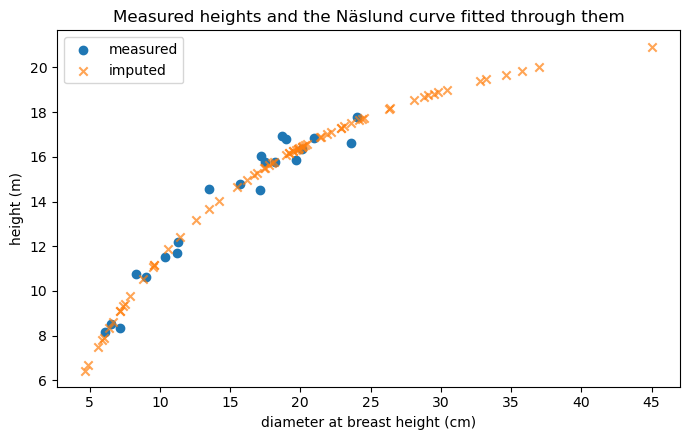

In [5]:
fig, ax = plt.subplots(figsize=(7, 4.5))
for label, marker, alpha in (("measured", "o", 1.0), ("imputed", "x", 0.7)):
    subset = summary[summary["provenance"] == label]
    ax.scatter(subset["dbh_cm"], subset["height_m"], marker=marker, alpha=alpha, label=label)
ax.set_xlabel("diameter at breast height (cm)")
ax.set_ylabel("height (m)")
ax.set_title("Measured heights and the Näslund curve fitted through them")
ax.legend()
fig.tight_layout()
plt.show()

The imputed points lie exactly on the fitted curve, which is what an
interpolated value *is* -- it carries no residual scatter. The measured points
scatter around it. Anything that treats the two alike will understate the
variance it is working with.

## 3. Competition indices

`competition_indices` takes a plot (or a stand, or a plain list of trees), the
indices you want, and a rule for choosing competitors. Here are three indices
with contrasting behaviour:

- **`Heg`** (Hegyi 1974) -- distance-dependent size ratio; higher means more
  competition.
- **`BAL`** (Wykoff et al. 1982) -- basal area of larger trees, distance
  independent.
- **`drg`** (Hamilton 1986) -- the subject's diameter over the plot's quadratic
  mean diameter. Note this one runs the *other* way: a high value means the
  subject dominates.

In [6]:
plot = stand.plots[0]
results = competition_indices(
    plot,
    indices=["Heg", "BAL", "drg"],
    selector=FixedRadius(8.0, min_size_ratio=0.3),
)

table = pd.DataFrame(
    {
        "uid": [r.tree.uid for r in results],
        "dbh_cm": [float(r.tree.diameter_cm) for r in results],
        "n_comp": [r.n_competitors for r in results],
        **{name: [r.indices[name] for r in results] for name in ("Heg", "BAL", "drg")},
    }
).sort_values("dbh_cm")

print(table.head(5).round(3).to_string(index=False))
print("   ...")
print(table.tail(5).round(3).to_string(index=False))

  uid  dbh_cm  n_comp    Heg    BAL   drg
p1t37     4.7      19 24.554 16.702 0.252
p1t31     4.9      29 31.089 26.955 0.263
p1t02     5.6      13 23.026 13.298 0.300
p1t20     5.9      19 26.137 16.096 0.316
p1t28     6.1      24 20.130 20.715 0.327
   ...
  uid  dbh_cm  n_comp   Heg   BAL   drg
p1t29    24.4      24 5.038 4.946 1.308
p1t25    26.3      12 3.517 3.204 1.410
p1t11    26.4      21 3.837 0.000 1.415
p1t44    34.6      10 3.183 0.000 1.854
p1t34    35.8      11 1.814 0.000 1.919


Small trees carry high `Heg` and `BAL` and low `drg`; large trees the reverse.
That is the sanity check you want -- a suppressed stem is under more competition
than a dominant one.

In the correlation below, `drg` sits at exactly 1.000 against diameter. That is
not a finding: `drg` *is* the subject's diameter divided by a plot-level
constant, so within one plot it is diameter on a different scale. It earns its
place as a predictor across plots of differing size, not within one.

In [7]:
print(table[["dbh_cm", "Heg", "BAL", "drg"]].corr().round(3).to_string())

        dbh_cm    Heg    BAL    drg
dbh_cm   1.000 -0.870 -0.688  1.000
Heg     -0.870  1.000  0.532 -0.870
BAL     -0.688  0.532  1.000 -0.688
drg      1.000 -0.870 -0.688  1.000


## 4. The selection rule is part of the index

An index value is only interpretable next to the rule that chose its
competitors. The same `Heg` formula on the same plot gives materially different
numbers under different rules, so the rule has to be reported alongside the
index.

In [8]:
selectors = {
    "FixedRadius(8 m)": FixedRadius(8.0),
    "MeanHeightRadius(0.4)": MeanHeightRadius(0.4),
    "MeanHeightRadius(0.25)": MeanHeightRadius(0.25),
    "LeeGadowRadius(k=2)": LeeGadowRadius(2.0),
    "LeeGadowRadius(k=3)": LeeGadowRadius(3.0),
    "BitterlichBAF(2)": BitterlichBAF(2.0),
    "NearestNeighbours(4)": NearestNeighbours(4),
    "SearchCone(80 deg)": SearchCone(80.0),
}

rows = []
for label, selector in selectors.items():
    res = competition_indices(plot, indices=["Heg"], selector=selector)
    src = selector_source(selector)
    rows.append(
        {
            "selector": label,
            "mean_competitors": sum(r.n_competitors for r in res) / len(res),
            "mean_Heg": sum(r.indices["Heg"] for r in res) / len(res),
            "citation": f"{src.author.split(',')[0]} {src.year}" if src else "(plain geometry)",
        }
    )

print(pd.DataFrame(rows).round(3).to_string(index=False))

              selector  mean_competitors  mean_Heg         citation
      FixedRadius(8 m)            18.533    10.012 (plain geometry)
 MeanHeightRadius(0.4)            10.578     6.891        Sims 2009
MeanHeightRadius(0.25)             4.444     4.191        Sims 2009
   LeeGadowRadius(k=2)             9.067     6.283         Lee 1997
   LeeGadowRadius(k=3)            18.133     9.868         Lee 1997
      BitterlichBAF(2)            13.000     5.443  Bitterlich 1952
  NearestNeighbours(4)             4.000     3.971 (plain geometry)
    SearchCone(80 deg)            31.289    18.337    Pretzsch 2009


Note how far apart these are. Every number in these rules is a *parameter*
with a literature default, not a constant: `MeanHeightRadius(0.4)` uses the
fraction Sims et al. (2009) tested, and dropping it to 0.25 shrinks the zone and
the index with it.

`SearchCone` looks indiscriminate here, and at this scale it is: an 80 degree
cone reaches `h / tan(50 deg)` horizontally, so a 20 m neighbour competes out to
almost 17 m -- further than this 10 m plot is wide. The cone discriminates on
larger neighbourhoods, or at a narrower angle. It is the one rule here whose
reach depends on the *neighbour's* size rather than the subject's, which is why
it behaves so differently from the rest.

### The two screens

The comparison this set is drawn from applies two screens together for its
influence-zone approaches: a neighbour must be at least 30% of the subject's
diameter, *and* must not stand in the shadow of a nearer competitor within 30
degrees. Reproducing those approaches needs both.

In [9]:
screens = {
    "no screens": FixedRadius(8.0),
    "size only (0.3)": FixedRadius(8.0, min_size_ratio=0.3),
    "shadow only (30 deg)": FixedRadius(8.0, elimination_angle_deg=30.0),
    "both": FixedRadius(8.0, min_size_ratio=0.3, elimination_angle_deg=30.0),
}
for label, selector in screens.items():
    res = competition_indices(plot, indices=["Heg"], selector=selector)
    mean_n = sum(r.n_competitors for r in res) / len(res)
    mean_h = sum(r.indices["Heg"] for r in res) / len(res)
    print(f"{label:24s} mean competitors {mean_n:5.2f}   mean Heg {mean_h:6.3f}")

no screens               mean competitors 18.53   mean Heg 10.012
size only (0.3)          mean competitors 16.98   mean Heg  9.856
shadow only (30 deg)     mean competitors  9.11   mean Heg  6.849
both                     mean competitors  8.76   mean Heg  6.888


## 5. Edge correction

A tree near the plot boundary has part of its competition zone outside the plot,
so its distance-dependent indices come out too low. Each result reports
`observed_zone_fraction`, the share of the zone that was actually inside, and by
default the spatial indices are divided by it.

In [10]:
raw = competition_indices(
    plot, indices=["Heg"], selector=FixedRadius(8.0), edge_correction=None
)
corrected = competition_indices(plot, indices=["Heg"], selector=FixedRadius(8.0))

edge = pd.DataFrame(
    {
        "uid": [r.tree.uid for r in raw],
        "dist_from_centre_m": [
            round(((r.tree.position.X - plot.position.X) ** 2
                   + (r.tree.position.Y - plot.position.Y) ** 2) ** 0.5, 2)
            for r in raw
        ],
        "observed_fraction": [round(r.observed_zone_fraction, 3) for r in raw],
        "Heg_raw": [round(r.indices["Heg"], 3) for r in raw],
        "Heg_corrected": [round(r2.indices["Heg"], 3) for r2 in corrected],
    }
).sort_values("dist_from_centre_m")

print("Trees nearest the plot centre (zone fully observed):")
print(edge.head(3).to_string(index=False))
print("\nTrees nearest the boundary (zone partly outside):")
print(edge.tail(3).to_string(index=False))

Trees nearest the plot centre (zone fully observed):
  uid  dist_from_centre_m  observed_fraction  Heg_raw  Heg_corrected
p1t05                0.73              1.000    5.119          5.119
p1t28                1.43              1.000   20.130         20.130
p1t14                2.41              0.986    5.349          5.427

Trees nearest the boundary (zone partly outside):
  uid  dist_from_centre_m  observed_fraction  Heg_raw  Heg_corrected
p1t02                9.43              0.455   10.486         23.026
p1t18                9.45              0.454    8.708         19.171
p1t01                9.96              0.417    4.036          9.682


Only the boundary trees change; a tree whose whole zone is inside the plot has
`observed_fraction == 1.0` and is left alone. Non-spatial indices such as `BAL`
are never corrected -- they are plot-level sums and do not depend on where in
the plot the subject sits.

## 6. Where the numbers come from

Every index carries the citation of the paper that proposed it -- not the review
they were collected from. That means a result can always answer "according to
whom?".

In [11]:
catalogue = pd.DataFrame(
    [
        {
            "index": name,
            "spatial": entry.spatial,
            "author": index_source(name).author,
            "year": index_source(name).year,
        }
        for name, entry in INDEX_REGISTRY.items()
    ]
).sort_values(["spatial", "year"])
print(catalogue.to_string(index=False))

 index  spatial                                       author  year
 BA-gj    False                Steneker, G.A. & Jarvis, J.M.  1963
   BAL    False  Wykoff, W.R., Crookston, N.L. & Stage, A.R.  1982
   Sdr    False                                Lorimer, C.G.  1983
   drg    False                               Hamilton, D.A.  1986
  SBAr    False Daniels, R.F., Burkhart, H.E. & Clason, T.R.  1986
   BAr    False                     Corona, P. & Ferrara, A.  1989
  BALr    False                                Vanclay, J.K.  1991
BALMOD    False                 Schroder, J. & von Gadow, K.  1999
    Sl     True                               Staebler, G.R.  1951
   SOr     True                                Gerrard, D.J.  1969
  SOdr     True                                  Bella, I.E.  1971
   Heg     True                                    Hegyi, F.  1974
 SAng1     True                                    Lin, J.Y.  1974
 Almdg     True                                Alemdag, I.S.  

## Summary

- `Stand.impute("height_m")` fits Näslund's curve to the stand's own measured
  pairs and fills the gaps, keeping measured and modelled values distinct and
  recording which model produced each modelled one.
- `competition_indices(...)` computes any of the eighteen indices; pass
  `indices=` to choose and `selector=` to say how competitors are found.
- The selection rule is part of the result. Report it alongside the index, and
  treat its parameters as parameters -- the defaults are one study's choices.
- Distance-dependent indices are biased low at the plot edge;
  `observed_zone_fraction` reports the exposure and the default corrects for it.

### Next steps

- The influence-zone indices (`Sl`, `SOr`, `SOdr`) additionally need a crown
  radius. Supply one with `stand.impute("crown_radius_m", <callable>)` or the
  `crown_radius=` argument; a caller-supplied value is recorded as uncited.
- `SearchCone(apex="crown_base")` needs `crown_base_height_m`, which can be
  imputed the same way.